In [15]:
## Science Data (Pixel data format)

from astropy.io import fits

data_dir = '/home/jashhwanth/Desktop/solarflare/14_May_2024_New/' 
fits_filename = data_dir+'solo_L1_stix-sci-xray-cpd_20240514T121658-20240514T133515_V02_2405141598-50408.fits'

# open the fits file
hdulist=fits.open(fits_filename)
header=hdulist[2].header
print(header)

# parse time which is given as seconds since the beginning of the observation
time_sod=hdulist[2].data.field('time')
print(time_sod)


# parse counts - (time, 32 detectors, 12 pixels, 32 energy bins)
counts = hdulist[2].data.field('counts')
#print(counts.shape)


print(hdulist[4].columns.names)
# produce energy labels
energy_labels = [str(x)+'-'+str(y)+' keV' for x,y in zip(hdulist[4].data['e_low'],hdulist[4].data['e_high'])]

# read energy information
energy_edges = [e_low+(e_high-e_low) for chn,e_low,e_high in hdulist[4].data]
energy_edges.insert(0,0)
mean_energy = [(e_high+e_low)/2 for chn,e_low,e_high in hdulist[4].data]

print(energy_edges)
print(mean_energy)

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                26295 / length of dimension 1                          NAXIS2  =                  236 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                   11 / number of table fields                         TTYPE1  = 'time    '                                                            TFORM1  = 'J       '                                                            TUNIT1  = 'cs      '                                                            TSCAL1  =                    1                                                  TZERO1  =           2147483648          

In [16]:
from astropy.io import fits

# change the next line to the path to the STIX data on your machine
data_dir = '/home/jashhwanth/Desktop/solarflare/14_May_2024_New/' 
fits_filename = data_dir+'solo_L1_stix-sci-xray-cpd_20240514T121658-20240514T133515_V02_2405141598-50408.fits'

# open the fits file
hdulist = fits.open(fits_filename)
header = hdulist[0].header
# parse time which is given as seconds since the beginning of the observation
time_sod = hdulist[2].data.field('time')
# parse counts - (time, 32 detectors, 12 pixels, 32 energy bins)
counts = hdulist[2].data.field('counts')
# produce energy labels
energy_labels = [str(x)+'-'+str(y)+' keV' for x,y in zip(hdulist[4].data['e_low'],hdulist[4].data['e_high'])]
# read energy information
energy_edges = [e_low+(e_high-e_low) for chn,e_low,e_high in hdulist[4].data]
energy_edges.insert(0,0)
mean_energy = [(e_high+e_low)/2 for chn,e_low,e_high in hdulist[4].data]



print(time_sod)

[  1020   3065   5180   7295   9360  11425  13530  15635  17715  19750
  21865  23985  26065  28240  30430  32525  34620  36780  38860  40930
  43035  45150  47235  49250  51300  53365  55400  57460  59540  61615
  63650  65670  67725  69795  71845  73865  75870  77870  79870  81870
  83870  85870  87870  89870  91870  93870  95870  97870  99870 101870
 103860 105860 107860 109860 111860 113860 115860 117860 119860 121860
 123870 125870 127870 129870 131870 133870 135870 137870 139870 141870
 143870 145870 147870 149870 151870 153870 155870 157870 159870 161870
 163870 165870 167870 169870 171870 173870 175870 177870 179070 180070
 181870 183870 185870 187870 189870 191870 193870 195870 197870 199870
 201870 203870 205870 207870 209870 211870 213870 215870 217870 219870
 221870 223870 225870 227870 229470 230470 231870 233870 235870 237870
 239870 241870 243870 245870 247870 249870 251870 253870 255870 257870
 259870 261870 263870 265870 267870 269870 271870 273870 275870 277870
 27987

In [17]:
from functools import partial
from datetime import datetime
from datetime import timedelta
import numpy as np

def convert_seconds_datetime(sod_i,date_obs):
    ''' 
    Function takes in seconds of day and the date of the observation as argument and returns
    a datetime object in a specified format
    '''
    for fmt in ('%Y-%m-%dT%H:%M:%S.%f', '%Y-%m-%dT%H:%M:%S'):
        try:
            # print(int(sod_i))
            # print(timedelta(seconds=int(sod_i)))
            # print(datetime.strptime(date_obs,fmt)+timedelta(seconds=int(sod_i)))
            return datetime.strptime(date_obs,fmt)+timedelta(seconds=int(sod_i)/100)
        except:
            pass
            
map_func = partial(convert_seconds_datetime, date_obs=hdulist[0].header['DATE-BEG'])
time_arr = np.asarray(list(map(map_func,time_sod)))

print(time_arr)
print(hdulist[0].header['DATE-BEG'])

[datetime.datetime(2024, 5, 14, 12, 17, 8, 957000)
 datetime.datetime(2024, 5, 14, 12, 17, 29, 407000)
 datetime.datetime(2024, 5, 14, 12, 17, 50, 557000)
 datetime.datetime(2024, 5, 14, 12, 18, 11, 707000)
 datetime.datetime(2024, 5, 14, 12, 18, 32, 357000)
 datetime.datetime(2024, 5, 14, 12, 18, 53, 7000)
 datetime.datetime(2024, 5, 14, 12, 19, 14, 57000)
 datetime.datetime(2024, 5, 14, 12, 19, 35, 107000)
 datetime.datetime(2024, 5, 14, 12, 19, 55, 907000)
 datetime.datetime(2024, 5, 14, 12, 20, 16, 257000)
 datetime.datetime(2024, 5, 14, 12, 20, 37, 407000)
 datetime.datetime(2024, 5, 14, 12, 20, 58, 607000)
 datetime.datetime(2024, 5, 14, 12, 21, 19, 407000)
 datetime.datetime(2024, 5, 14, 12, 21, 41, 157000)
 datetime.datetime(2024, 5, 14, 12, 22, 3, 57000)
 datetime.datetime(2024, 5, 14, 12, 22, 24, 7000)
 datetime.datetime(2024, 5, 14, 12, 22, 44, 957000)
 datetime.datetime(2024, 5, 14, 12, 23, 6, 557000)
 datetime.datetime(2024, 5, 14, 12, 23, 27, 357000)
 datetime.datetime(20

In [57]:
from astropy.io import fits

# Load the FITS file
fits_filename = '/home/jashhwanth/Desktop/solarflare/14_May_2024_New/solo_L1_stix-sci-xray-cpd_20240514T162700-20240514T190550_V02_2405143076-50414(1).fits'
hdulist = fits.open(fits_filename)

# Loop through each HDU
for i, hdu in enumerate(hdulist):
    print(f"\n===== HDU {i}: {hdu.name} =====")
    
    # Print header keys
    print("Header keys:")
    for key in list(hdu.header.keys())[:10]:  # Limit to first 10 keys for brevity
        print(f"  {key}: {hdu.header[key]}")
    
    # If it's a table HDU, print column names and formats
    if isinstance(hdu, fits.BinTableHDU):
        print("\nColumns:")
        for col in hdu.columns:
            print(f"  {col.name} ({col.format})")

# Close the file
# hdulist.close()



===== HDU 0: PRIMARY =====
Header keys:
  SIMPLE: True
  BITPIX: 8
  NAXIS: 0
  EXTEND: True
  FILENAME: solo_L1_stix-sci-xray-cpd_20240514T162700-20240514T190550_V02_2405143076-50414.fits
  RAW_FILE: TM_hourly_req_BatchRequest.PktTmRaw.SOL.0.2024.184.14.18.06.673.Vkfh@2024.188.08.00.01.588.9.xml
  PARENT: solo_L0_stix-sci-xray-cpd_0769018989-0769028519_V02_2405143076-50414.fits
  DATE: 2024-07-06T10:37:05.280
  BLANK: 4294967295
  LEVEL: L1

===== HDU 1: CONTROL =====
Header keys:
  XTENSION: BINTABLE
  BITPIX: 8
  NAXIS: 2
  NAXIS1: 3633
  NAXIS2: 1
  PCOUNT: 0
  GCOUNT: 1
  TFIELDS: 12
  TTYPE1: tc_packet_id_ref
  TFORM1: I

Columns:
  tc_packet_id_ref (I)
  tc_packet_seq_control (I)
  request_id (J)
  num_substructures (852I)
  index (B)
  packet (852I)
  raw_file (96A)
  parent (73A)
  compression_scheme_counts_skm (3B)
  compression_scheme_triggers_skm (3B)
  energy_bin_edge_mask (33B)
  time_stamp (D)

===== HDU 2: DATA =====
Header keys:
  XTENSION: BINTABLE
  BITPIX: 8
  NAXI

In [29]:

print(hdulist[3].columns.names)

# hdu3=hdulist[3]

obt_start = hdulist[3].data.field('obt_start')
obs_end = hdulist[3].data.field('obt_end')

print(obt_start,obs_end)

timeInt= obs_end-obt_start
print(timeInt)

timestamp= hdulist[1].data.field('time_stamp')
print(timestamp)

timedel=hdulist[2].data.field('timedel')
print(timedel)

times=hdulist[2].data.field('time')
print(times)

['version', 'obt_start', 'obt_end']
[7.73539383e+08] [7.73542407e+08]
[3023.92100406]
[7.69003985e+08]
[2040 2050 2180 2070 2040 2090 2120 2090 2070 2000 2230 2010 2150 2200
 2180 2010 2180 2140 2020 2120 2090 2140 2030 2000 2100 2030 2040 2080
 2080 2070 2000 2040 2070 2070 2030 2010 2000 2000 2000 2000 2000 2000
 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000
 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000
 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000
 2000 2000 2000 2000  400 1600 2000 2000 2000 2000 2000 2000 2000 2000
 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000
 2000 2000 1200  800 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000
 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000
 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000
 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000 2000
 2000 2000 2000 2000 2000 2000 2000 2000 2000

DATE-BEG from header: 2024-05-14T12:16:58.757
Parsed with format: %Y-%m-%dT%H:%M:%S.%f


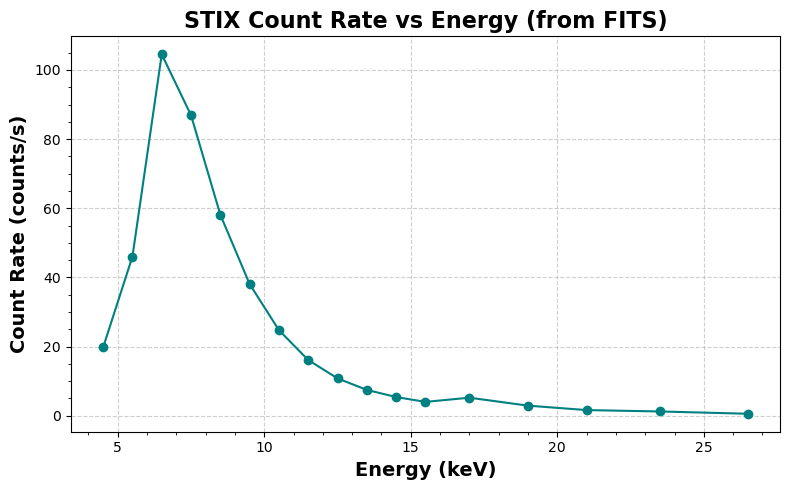

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from datetime import datetime, timedelta
from functools import partial

# Load FITS file
data_dir = '/home/jashhwanth/Desktop/solarflare/14_May_2024_New/' 
fits_filename = data_dir+'solo_L1_stix-sci-xray-cpd_20240514T121658-20240514T133515_V02_2405141598-50408.fits'
hdulist = fits.open(fits_filename)

time_sod = hdulist[2].data.field('time')
counts = hdulist[2].data.field('counts')

mean_energy = [(e_high + e_low) / 2 for chn, e_low, e_high in hdulist[4].data]
mean_energy = np.array(mean_energy)

# date_obs = hdulist[0].header['DATE-BEG']
print(f"DATE-BEG from header: {date_obs}")

for fmt in ('%Y-%m-%dT%H:%M:%S.%f', '%Y-%m-%dT%H:%M:%S', '%Y-%m-%dT%H:%M:%S%z'):
    try:
        dt0 = datetime.strptime(date_obs, fmt)
        print(f"Parsed with format: {fmt}")
        break
    except Exception as e:
        print(f"Failed with format {fmt}: {e}")


date_obs = hdulist[0].header['DATE-BEG']  # or DATE_OBS etc.
map_func = partial(convert_seconds_datetime, date_obs=date_obs)

# Filter out None values
time_arr = np.array([dt0 + timedelta(seconds=float(s)) for s in time_sod])



# Now this will work
duration_seconds = (time_arr[-1] - time_arr[0]).total_seconds()

total_counts_per_energy = counts.sum(axis=(0, 1, 2))
count_rate = total_counts_per_energy / duration_seconds

plt.figure(figsize=(8, 5))
plt.plot(mean_energy, count_rate, marker='o', linestyle='-', color='teal')
plt.xlabel("Energy (keV)", fontsize=14, fontweight='bold')
plt.ylabel("Count Rate (counts/s)", fontsize=14, fontweight='bold')
plt.title("STIX Count Rate vs Energy (from FITS)", fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.minorticks_on()
plt.tight_layout()
plt.show()

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                41655 / length of dimension 1                          NAXIS2  =                  473 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                   11 / number of table fields                         TTYPE1  = 'time    '                                                            TFORM1  = 'J       '                                                            TUNIT1  = 'cs      '                                                            TSCAL1  =                    1                                                  TZERO1  =           2147483648          

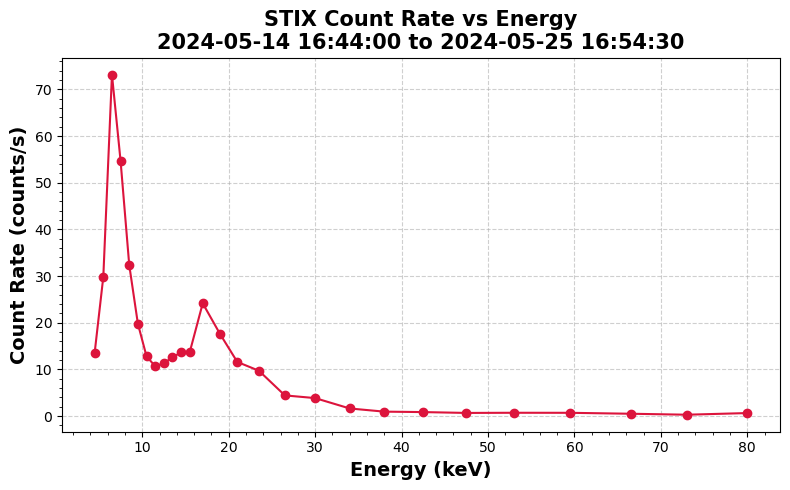

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from datetime import datetime, timedelta

# === Load FITS ===
data_dir = '/home/jashhwanth/Desktop/solarflare/14_May_2024_New/' 
fits_filename = data_dir+'solo_L1_stix-sci-xray-cpd_20240514T162700-20240514T190550_V02_2405143076-50414(1).fits'
hdulist = fits.open(fits_filename)

# === Time conversion ===
time_sod = hdulist[2].data.field('time')
date_obs = hdulist[0].header['DATE-BEG']
dt0 = datetime.strptime(date_obs, "%Y-%m-%dT%H:%M:%S.%f")
time_arr = np.array([dt0 + timedelta(seconds=float(s)) for s in time_sod])
print(hdulist[2].header,hdulist[0].header,hdulist[1].header,time_sod.shape,time_sod)

# === Energy info ===
counts = hdulist[2].data.field('counts')  # shape (time, 32 det, 12 pix, 32 energy)
mean_energy = np.array([(e_high + e_low) / 2 for chn, e_low, e_high in hdulist[4].data])

# === Define desired time range (UTC) ===
start_time = datetime(2024, 5, 14, 16, 44, 00)
end_time   = datetime(2024, 5, 25, 16, 54, 30)
# === Filter time indices ===
time_mask = (time_arr >= start_time) & (time_arr <= end_time)
filtered_indices = np.where(time_mask)[0]

# === Extract and sum counts over that time range ===
if len(filtered_indices) == 0:
    raise ValueError("No data in selected time range!")

filtered_counts = counts[filtered_indices, :, :, :]  # (t, 32, 12, 32)
total_counts = filtered_counts.sum(axis=(0, 1, 2))    # sum over time, detectors, pixels
duration_seconds = (time_arr[filtered_indices[-1]] - time_arr[filtered_indices[0]]).total_seconds()
count_rate = total_counts / duration_seconds

# === Plot ===
plt.figure(figsize=(8, 5))
plt.plot(mean_energy, count_rate, marker='o', linestyle='-', color='crimson')
plt.xlabel("Energy (keV)", fontsize=14, fontweight='bold')
plt.ylabel("Count Rate (counts/s)", fontsize=14, fontweight='bold')
plt.title(f"STIX Count Rate vs Energy\n{start_time} to {end_time}", fontsize=15, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.minorticks_on()
plt.tight_layout()
plt.show()


In [50]:
print("Start of data:", time_arr[0])
print("End of data:  ", time_arr[-1])

print(time_arr[:10])


Start of data: 2024-05-14 16:44:00.784000
End of data:   2024-05-25 16:54:20.784000
[datetime.datetime(2024, 5, 14, 16, 44, 0, 784000)
 datetime.datetime(2024, 5, 14, 17, 17, 55, 784000)
 datetime.datetime(2024, 5, 14, 17, 51, 45, 784000)
 datetime.datetime(2024, 5, 14, 18, 26, 40, 784000)
 datetime.datetime(2024, 5, 14, 19, 3, 10, 784000)
 datetime.datetime(2024, 5, 14, 19, 40, 20, 784000)
 datetime.datetime(2024, 5, 14, 20, 18, 25, 784000)
 datetime.datetime(2024, 5, 14, 20, 54, 55, 784000)
 datetime.datetime(2024, 5, 14, 21, 28, 55, 784000)
 datetime.datetime(2024, 5, 14, 22, 3, 5, 784000)]


In [44]:
print("Total summed counts in range:", filtered_counts.sum())

print(mean_energy)


Total summed counts in range: 14340
[ 4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5 14.5 15.5 17.  19.
 21.  23.5 26.5]
